In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
sanji = pd.read_csv("TRAIN_산지공판장_2018-2021.csv")
wholesale = pd.read_csv("TRAIN_전국도매_2018-2021.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
sanji.shape
sanji["품목명"].unique()

array(['감자', '사과', '배', '배추', '상추', '무', '양파', '대파', '마늘', '순무'],
      dtype=object)

In [ ]:
wholesale.shape
wholesale["품목명"].unique()

array(['감자', '사과', '배', '배추', '상추', '순무', '무', '양파', '대파', '마늘'],
      dtype=object)

In [ ]:
for df in [sanji, wholesale]:
    df["품목명"] = df["품목명"].astype(str).str.strip()
    df["품종명"] = df["품종명"].astype(str).str.strip()

if "등급명" in sanji.columns:
    sanji["등급명"] = sanji["등급명"].astype(str).str.strip()

# =========================
# 3. 타겟 정의 (리스트 형태로 통일)
# =========================
target_dict = {
    "건고추": ["화건"],
    "사과": ["홍로", "후지"],
    "감자": ["수미"],
    "배": ["신고"],
    "마늘": ["깐마늘"],   # 필요시 수정 가능
    "무": ["무"],
    "상추": ["청상추"],
    "배추": ["배추"],
    "양파": ["양파"],
    "대파": ["대파(일반)"]
}

# 등급 조건 (산지 전용)
grade_dict = {
    "건고추": "상",
    "사과": "상",
    "감자": "상",
    "배": "상",
    "마늘": "상",
    "무": "상",
    "상추": "상",
    "배추": "상",
    "양파": "상",
    "대파": "상"
}

# =========================
# 4. 산지공판장 필터링 (등급 포함)
# =========================
sanji_list = []

for item in target_dict:
    temp = sanji[
        (sanji["품목명"] == item) &
        (sanji["품종명"].isin(target_dict[item])) &
        (sanji["등급명"] == grade_dict[item])
    ]
    sanji_list.append(temp)

sanji_target = pd.concat(sanji_list, ignore_index=True)

# =========================
# 5. 전국도매 필터링 (등급 없음)
# =========================
wholesale_list = []

for item in target_dict:
    temp = wholesale[
        (wholesale["품목명"] == item) &
        (wholesale["품종명"].isin(target_dict[item]))
    ]
    wholesale_list.append(temp)

wholesale_target = pd.concat(wholesale_list, ignore_index=True)

# =========================
# 6. 결과 확인
# =========================
print("산지 데이터:")
print(sanji_target["품목명"].value_counts())

print("\n도매 데이터:")
print(wholesale_target["품목명"].value_counts())

wholesale_target.head()


산지 데이터:
품목명
사과    2316
배     1902
감자     773
대파     513
마늘     303
상추      12
Name: count, dtype: int64

도매 데이터:
품목명
사과    5691
배     4650
대파    4613
상추    4607
감자    4228
마늘    3990
배추     841
양파     646
무      594
Name: count, dtype: int64


,시점,시장코드,시장명,품목코드,품목명,품종코드,품종명,총반입량(kg),총거래금액(원),평균가(원/kg),...,저가(20%) 평균가,중간가(원/kg),최저가(원/kg),최고가(원/kg),경매 건수,전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,연도
0,201801상순,100000,*전국도매시장,601,사과,60103,후지,4421982.3,8056837500,1821.996777,...,940.431303,1567.500000,160.0,6750.000000,4983,20489.82867,19563.37872,21379.55055,29947.58348,2018
1,201801상순,110001,서울가락,601,사과,60103,후지,551733.3,1249110800,2263.975729,...,1274.808748,1975.298805,500.0,5600.000000,223,19270.32821,16854.20028,20067.29830,32387.93194,2018
2,201801상순,110008,서울강서,601,사과,60103,후지,85988.0,149489500,1738.492580,...,1166.311242,1667.311242,550.0,2737.692308,72,17521.08081,16050.89720,21745.15047,0.00000,2018
3,201801상순,210001,부산엄궁,601,사과,60103,후지,160210.0,258727300,1614.926035,...,925.803790,1347.200000,380.0,3888.888889,113,16877.15067,14149.09002,17170.73093,23725.15238,2018
4,201801상순,210009,부산반여,601,사과,60103,후지,116475.0,186145500,1598.158403,...,1043.420216,1452.898551,350.0,3665.573770,91,15093.03281,13228.38541,20854.44007,22525.68434,2018


In [ ]:
train["품목명"] = train["품목명"].astype(str).str.strip()
train["품종명"] = train["품종명"].astype(str).str.strip()
train["등급"] = train["등급"].astype(str).str.strip()

In [ ]:
target_map = {
    "건고추": {"품종": ["화건"], "등급": "상품", "거래단위": "30 kg"},

    "사과": {"품종": ["홍로", "후지"], "등급": "상품", "거래단위": "10 개"},

    "감자": {"품종": ["감자 수미"], "등급": "상", "거래단위": "20키로상자"},

    "배": {"품종": ["신고"], "등급": "상품", "거래단위": "10 개"},

    "깐마늘(국산)": {"품종": ["깐마늘(국산)"], "등급": "상품", "거래단위": "20 kg"},

    "무": {"품종": ["무"], "등급": "상", "거래단위": "20키로상자"},

    "상추": {"품종": ["청"], "등급": "상품", "거래단위": "100 g"},

    "배추": {"품종": ["배추"], "등급": "상", "거래단위": "10키로망대"},

    "양파": {"품종": ["양파"], "등급": "상", "거래단위": "1키로"},

    "대파": {"품종": ["대파(일반)"], "등급": "상", "거래단위": "1키로단"},
}

train["품목명"] = train["품목명"].astype(str).str.strip()
train["품종명"] = train["품종명"].astype(str).str.strip()
train["등급"] = train["등급"].astype(str).str.strip()

train_list = []

for item, info in target_map.items():

    if len(info["품종"]) > 1:
        cond_variety = train["품종명"].isin(info["품종"])
    else:
        cond_variety = train["품종명"] == info["품종"][0]

    temp = train[
        (train["품목명"] == item) &
        cond_variety &
        (train["등급"] == info["등급"]) &
        (train["거래단위"] == info["거래단위"])
    ]

    print(item, len(temp))

    train_list.append(temp)

train_target = pd.concat(train_list, ignore_index=True)

print(train_target["품목명"].value_counts())
train_target.head()
train_target.to_excel("train_target.xlsx", index=False)

건고추 144
사과 144
감자 144
배 144
깐마늘(국산) 144
무 144
상추 144
배추 144
양파 144
대파 144
품목명
건고추        144
사과         144
감자         144
배          144
깐마늘(국산)    144
무          144
상추         144
배추         144
양파         144
대파         144
Name: count, dtype: int64


In [ ]:
(train_target == 0).sum()

,0
시점,0
품목명,0
품종명,0
거래단위,0
등급,0
평년 평균가격(원),295
평균가격(원),0


In [ ]:
# 1. 0 → NaN
train_target["평년 평균가격(원)"] = train_target["평년 평균가격(원)"].replace(0, np.nan)

# 2. 시계열 선형 보간 (가능한 품종 : 사과 후지, 건고추 화건)
train_target["평년 평균가격(원)"] = train_target.groupby(
    ["품목명","품종명"]
)["평년 평균가격(원)"].transform(lambda x: x.interpolate().ffill().bfill())

# 3. 월 기반 보간 - 무, 깐마늘 국산
train_target["월"] = train_target["시점"].str[4:6].astype(int)

train_target["평년 평균가격(원)"] = train_target["평년 평균가격(원)"].fillna(
    train_target.groupby(["품목명","품종명","월"])["평균가격(원)"].transform("mean")
)

# 4. 품목 평균 fallback
train_target["평년 평균가격(원)"] = train_target["평년 평균가격(원)"].fillna(
    train_target.groupby("품목명")["평균가격(원)"].transform("mean")
)

In [ ]:
(train_target == 0).sum()
train_target.to_excel("train_target.xlsx", index=False)


NameError: name 'train_target' is not defined

In [ ]:
import numpy as np

# 1️⃣ IQR 기준 구하기
Q1 = train_target["평균가격(원)"].quantile(0.25)
Q3 = train_target["평균가격(원)"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 2️⃣ clip 적용
train_target["price_clipped"] = train_target["평균가격(원)"].clip(lower=lower, upper=upper)

# 3️⃣ log 변환
train_target["log_price"] = np.log1p(train_target["price_clipped"])

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

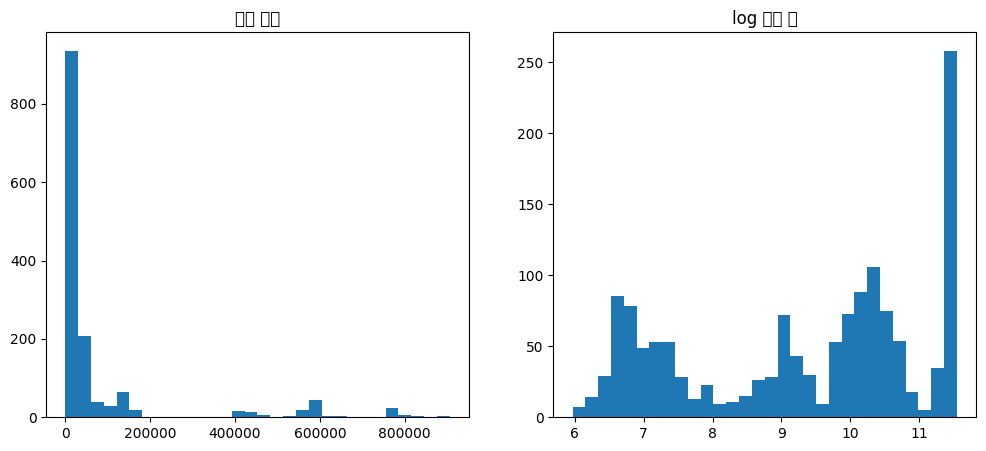

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(train_target["평균가격(원)"], bins=30)
plt.title("원래 가격")

plt.subplot(1,2,2)
plt.hist(train_target["log_price"], bins=30)
plt.title("log 변환 후")

plt.show()

clip+log
이상치 완화
분포의 안정화
모델 성능 상승

In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

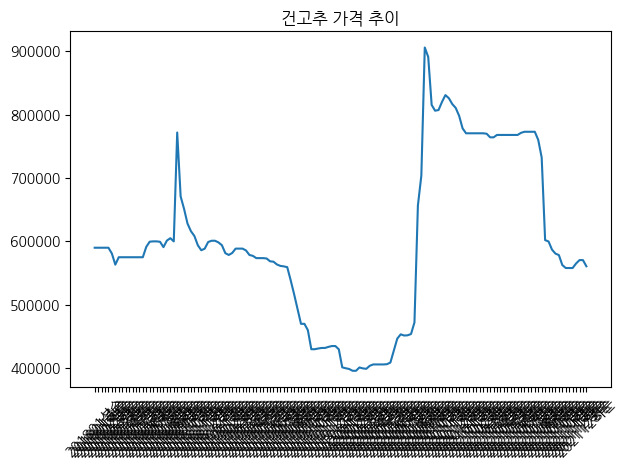

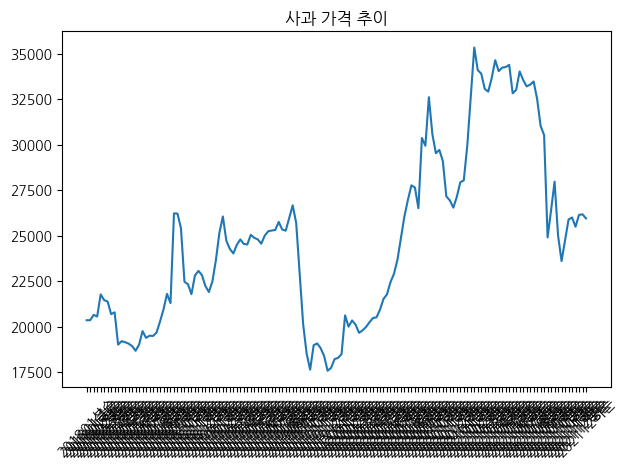

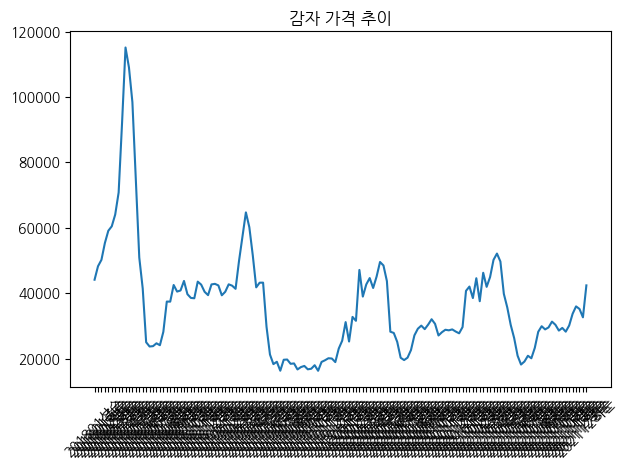

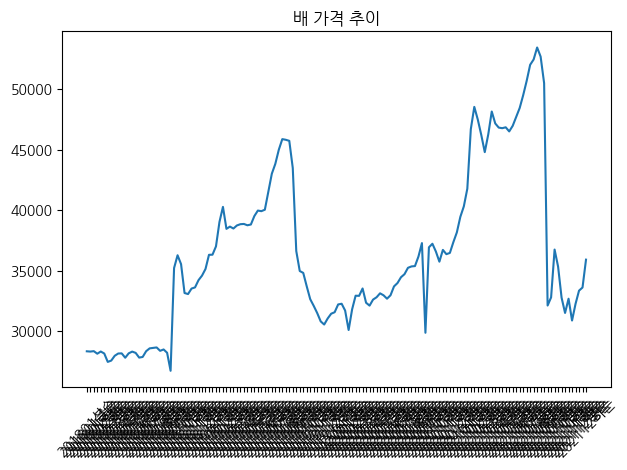

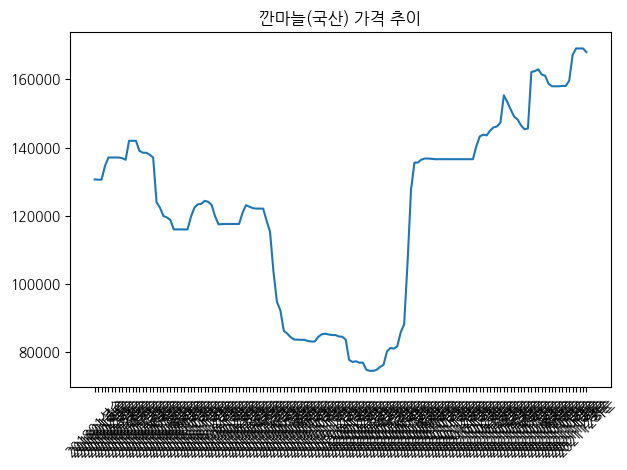

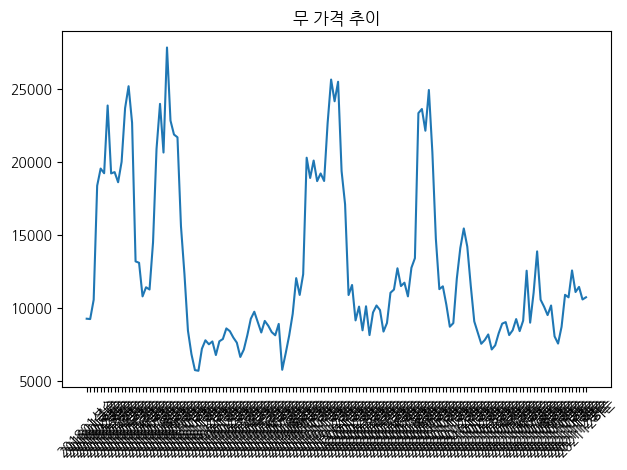

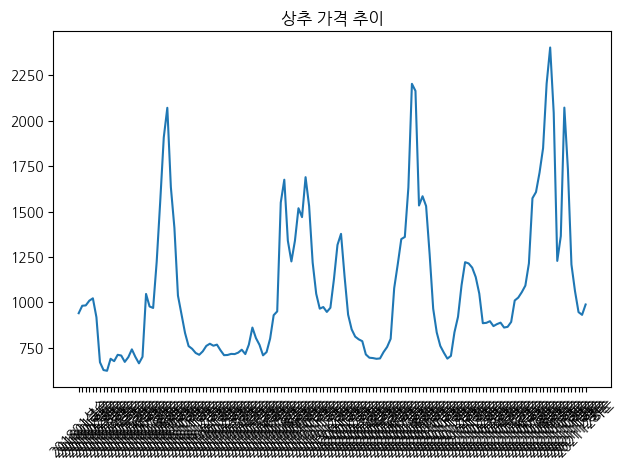

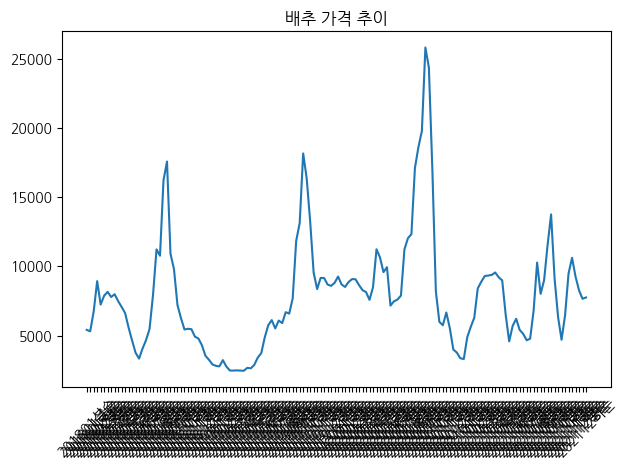

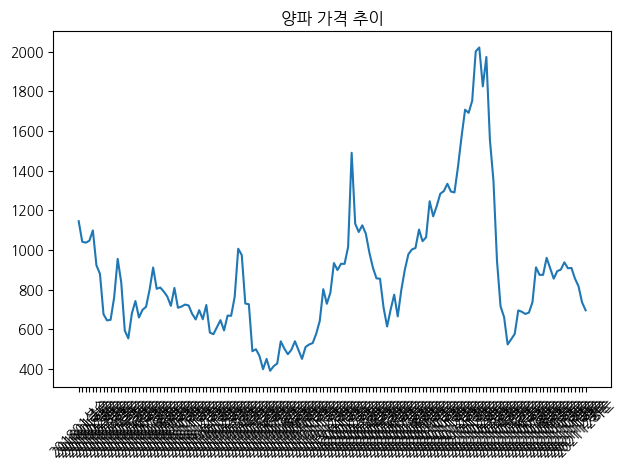

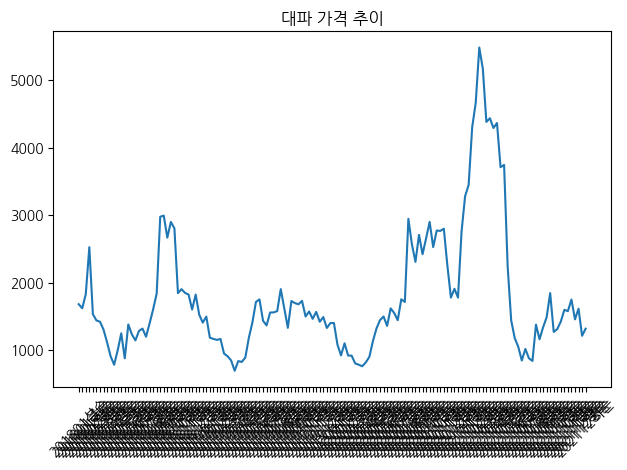

In [ ]:

items = train_target["품목명"].unique()

for item in items:
    df_item = train_target[train_target["품목명"] == item]

    plt.figure()
    plt.plot(df_item["시점"], df_item["평균가격(원)"])
    plt.title(f"{item} 가격 추이")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

NameError: name 'mdates' is not defined

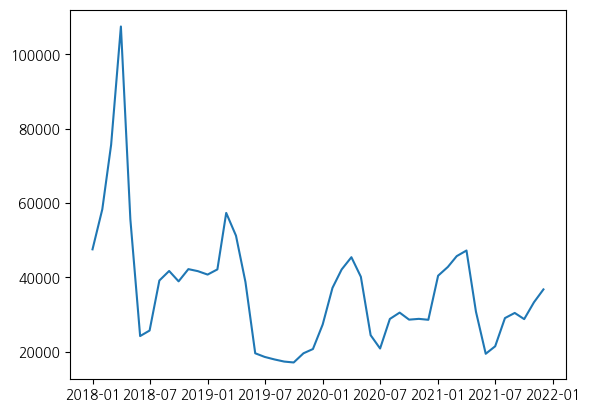

In [ ]:
# 날짜 생성
train_target["연도"] = train_target["시점"].str[:4].astype(int)
train_target["월"] = train_target["시점"].str[4:6].astype(int)

train_target["날짜"] = pd.to_datetime(
    train_target["연도"].astype(str) + "-" + train_target["월"].astype(str) + "-01"
)

# 🔥 월 평균으로 집계
monthly = train_target.groupby(
    ["품목명", "날짜"]
)["평균가격(원)"].mean().reset_index()

for item in monthly["품목명"].unique():
    df_item = monthly[monthly["품목명"] == item]

    plt.figure()
    plt.plot(df_item["날짜"], df_item["평균가격(원)"])

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.title(f"{item} 가격 추이")
    plt.xticks(rotation=45, fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
volatility = train_target.groupby("품목명")["평균가격(원)"].agg(
    mean="mean",
    std="std"
).reset_index()

volatility["cv"] = volatility["std"] / volatility["mean"]

volatility = volatility.sort_values("cv", ascending=False)

volatility

,품목명,mean,std,cv
3,대파,1785.862114,946.891808,0.530216
6,배추,7847.127714,4118.276746,0.524813
0,감자,36446.472495,16835.695832,0.461929
4,무,12669.117664,5536.419223,0.437001
9,양파,865.948851,332.813123,0.384333
8,상추,1062.298611,394.579870,0.371440
2,깐마늘(국산),122036.210648,27518.051370,0.225491
1,건고추,597980.802083,130256.492058,0.217827
7,사과,24809.940972,4848.511691,0.195426
5,배,36352.687500,6741.386965,0.185444


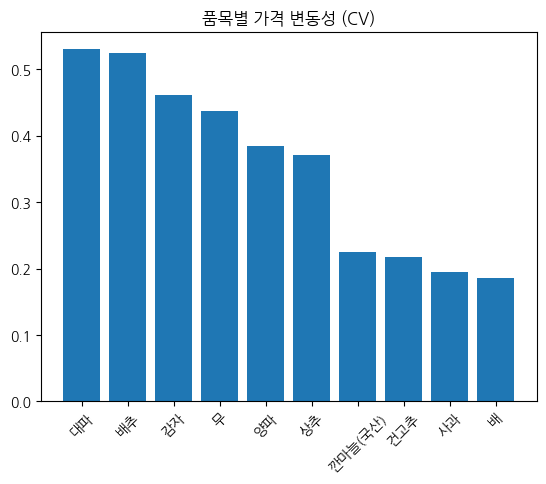

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(volatility["품목명"], volatility["cv"])
plt.title("품목별 가격 변동성 (CV)")
plt.xticks(rotation=45)
plt.show()

변동성 높은 그룹
대파 (~0.53), 배추 (~0.52)

매우 높음
가격 급등/급락 있음
이벤트 영향 큼

중간 변동성
감자 (~0.46), 무 (~0.44), 양파 (~0.38), 상추 (~0.37)

적당히 변동 있음
시계열 패턴 존재

낮은 변동성
깐마늘 (~0.23), 건고추 (~0.22), 사과 (~0.20), 배 (~0.19)

안정적
예측 쉬운 편

대파와 배추 - lag 많이 (1,2,3,6)
rolling 필수
이벤트 필수 (김장철)
lightgbm 추천
피처 :
lag_1, lag_2, lag_3
rolling_mean_3
rolling_std_3
김장철

중간 - 감자, 무, 양파, 상추
lag+rollling
일부 이벤트
LightGBM or XGB
Ridge or LightGBM (복잡도 낮은 모델)


In [ ]:
## 시간별 변동성 rolling

import matplotlib.pyplot as plt

train_target = train_target.sort_values(["품목명","날짜"])

train_target["rolling_std"] = train_target.groupby(
    ["품목명","품종명"]
)["평균가격(원)"].transform(lambda x: x.rolling(6).std())

In [ ]:
for item in train_target["품목명"].unique():
    df_item = train_target[train_target["품목명"] == item]

    plt.figure()
    plt.plot(df_item["날짜"], df_item["rolling_std"])

    plt.title(f"{item} 변동성 추이")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:

wholesale_agg = wholesale_target.groupby(
    ["품목명", "시점"]
)["총반입량(kg)"].sum().reset_index()

wholesale_agg.columns = ["품목명","시점","도매_총반입량"]


# Prepare monthly average wholesale volume for imputation in test data
wholesale_target_with_month = wholesale_target.copy()
wholesale_target_with_month["월"] = pd.to_datetime(wholesale_target_with_month["시점"].str[:6], format="%Y%m").dt.month
monthly_avg_wholesale_volume = wholesale_target_with_month.groupby(["품목명", "월"])["총반입량(kg)"].mean().reset_index()
monthly_avg_wholesale_volume.rename(columns={"총반입량(kg)": "도매_월평균_총반입량"}, inplace=True)

train_target = train_target.merge(
    wholesale_agg,
    on=["품목명","시점"],
    how="left"
)

train_target.head()

train_target["rolling_std"] = train_target.groupby(
    ["품목명","품종명"]
)["log_price"].transform(lambda x: x.rolling(3).std())

In [ ]:
train_target["rolling_std_3"] = train_target.groupby(
    ["품목명","품종명"]
)["log_price"].transform(lambda x: x.rolling(3).std())

train_target.head()

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원),월,price_clipped,log_price,...,vol_lag_1,log_wholesale_vol,wholesale_vol_lag_1,wholesale_vol_mean_3,price_per_vol,김장철,추석,is_test,도매_총반입량_y,도매_총반입량
0,201801상순,감자,감자 수미,20키로상자,상,24660.03175,44170.28571,1,44170.28571,10.695830,...,NaN,15.393952,NaN,NaN,0.009112,0,0,0,4847393.0,4847393.0
1,201801중순,감자,감자 수미,20키로상자,상,23299.44444,48283.77778,1,48283.77778,10.784872,...,NaN,15.227357,4847393.0,NaN,0.011766,0,0,0,4103525.2,4103525.2
2,201801하순,감자,감자 수미,20키로상자,상,25218.00741,50243.00000,1,50243.00000,10.824646,...,NaN,15.192379,4103525.2,4.304464e+06,0.012680,0,0,0,3962474.2,3962474.2
3,201802상순,감자,감자 수미,20키로상자,상,28703.87500,55380.66667,2,55380.66667,10.922004,...,3099.387777,15.542096,3962474.2,4.562475e+06,0.009852,0,0,0,5621426.4,5621426.4
4,201802중순,감자,감자 수미,20키로상자,상,27419.88228,59133.00000,2,59133.00000,10.987561,...,3665.151257,14.753546,5621426.4,4.046286e+06,0.023144,0,0,0,2554957.0,2554957.0


In [ ]:
# 피처 엔지니어링
##1. 시간 피처
##2. lag 피처
##3. rolling 피처
##4. 평년 기반 피처
##5. 변화율 피처
##6. 반입량 기반 피처


# 정렬
train_target = train_target.sort_values(["품목명","품종명","날짜"])

# =====================
# 1. 시간
# =====================
train_target["월"] = train_target["날짜"].dt.month
train_target["계절"] = train_target["월"] % 12 // 3

# =====================
# 2. lag
# =====================
for lag in [1,2,3]:
    train_target[f"lag_{lag}"] = train_target.groupby(
        ["품목명","품종명"]
    )["평균가격(원)"].shift(lag)

# =====================
# 3. rolling
# =====================
train_target["rolling_mean_3"] = train_target.groupby(
    ["품목명","품종명"]
)["평균가격(원)"].transform(lambda x: x.rolling(3).mean())

train_target["rolling_std_3"] = train_target.groupby(
    ["품목명","품종명"]
)["평균가격(원)"].transform(lambda x: x.rolling(3).std())

# =====================
# 4. 변화율
# =====================
train_target["pct_change"] = train_target.groupby(
    ["품목명","품종명"]
)["평균가격(원)"].pct_change()

# =====================
# 5. 평년
# =====================
train_target["price_vs_avg"] = train_target["평균가격(원)"] / train_target["평년 평균가격(원)"]
train_target["diff_avg"] = train_target["평균가격(원)"] - train_target["평년 평균가격(원)"]

# =====================
# 6. 변동성 lag
# =====================
train_target["vol_lag_1"] = train_target.groupby(
    ["품목명","품종명"]
)["rolling_std_3"].shift(1)

# =====================
# 7. 도매 반입량
# =====================
train_target["log_wholesale_vol"] = np.log1p(train_target["도매_총반입량"])

train_target["wholesale_vol_lag_1"] = train_target.groupby(
    "품목명"
)["도매_총반입량"].shift(1)

train_target["wholesale_vol_mean_3"] = train_target.groupby(
    "품목명"
)["도매_총반입량"].transform(lambda x: x.rolling(3).mean())

train_target["price_per_vol"] = train_target["평균가격(원)"] / (train_target["도매_총반입량"] + 1)


# =====================
# 8. 이벤트
# =====================
train_target["김장철"] = train_target["월"].isin([11,12]).astype(int)
train_target["추석"] = train_target["월"].isin([9,10]).astype(int)

#피처 리스트
features = [
    "월","계절",

    "lag_1","lag_2","lag_3",
    "rolling_mean_3","rolling_std_3",
    "pct_change",

    "price_vs_avg","diff_avg",

    "vol_lag_1",

    "log_wholesale_vol",
    "wholesale_vol_lag_1",
    "wholesale_vol_mean_3",
    "price_per_vol",

    "김장철",
    "추석"
]

In [ ]:
train_target.head()

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원),월,price_clipped,log_price,...,pct_change,price_vs_avg,diff_avg,vol_lag_1,log_wholesale_vol,wholesale_vol_lag_1,wholesale_vol_mean_3,price_per_vol,김장철,추석
0,201801상순,감자,감자 수미,20키로상자,상,24660.03175,44170.28571,1,44170.28571,10.695830,...,NaN,1.791169,19510.25396,NaN,15.393952,NaN,NaN,0.009112,0,0
1,201801중순,감자,감자 수미,20키로상자,상,23299.44444,48283.77778,1,48283.77778,10.784872,...,0.093128,2.072315,24984.33334,NaN,15.227357,4847393.0,NaN,0.011766,0,0
2,201801하순,감자,감자 수미,20키로상자,상,25218.00741,50243.00000,1,50243.00000,10.824646,...,0.040577,1.992346,25024.99259,NaN,15.192379,4103525.2,4.304464e+06,0.012680,0,0
3,201802상순,감자,감자 수미,20키로상자,상,28703.87500,55380.66667,2,55380.66667,10.922004,...,0.102256,1.929379,26676.79167,3099.387777,15.542096,3962474.2,4.562475e+06,0.009852,0,0
4,201802중순,감자,감자 수미,20키로상자,상,27419.88228,59133.00000,2,59133.00000,10.987561,...,0.067755,2.156574,31713.11772,3665.151257,14.753546,5621426.4,4.046286e+06,0.023144,0,0


# 모델링 품목별

In [ ]:
from lightgbm import LGBMRegressor

models = {}

for item in train_target["품목명"].unique():

    df_item = train_target[train_target["품목명"] == item]

    X = df_item[features]
    y = np.log1p(df_item["평균가격(원)"])  # log target

    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X, y)

    models[item] = model

In [ ]:
import zipfile
import os

zip_path = "테스트 압축 파일.zip"
extract_path = "test_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
test_files = sorted([
    os.path.join(extract_path, f)
    for f in os.listdir(extract_path)
    if f.endswith(".csv")
])

test_files

In [ ]:
import pandas as pd
import numpy as np
import re

def parse_test_time(x):
    nums = re.findall(r"\d+", str(x))
    return int(nums[0]) if nums else 0


def predict_one_file(test_path, models, train_target, features):

    test = pd.read_csv(test_path)
    test["rel_idx"] = test["시점"].apply(parse_test_time)

    # 마지막 날짜 기준
    last_date = train_target["날짜"].max()

    # 날짜 생성
    test["날짜"] = test["rel_idx"].apply(
        lambda x: last_date + pd.DateOffset(months=x)
    )

     # ======================
    # 🔥 seed 값 만들기
    # ======================
    last_price = train_target.groupby(["품목명","품종명"])["평균가격(원)"].last().reset_index()

    test = test.merge(last_price, on=["품목명","품종명"], how="left")

    # train + test 합치기
    train_copy = train_target.copy()
    train_copy["is_test"] = 0
    test["is_test"] = 1

    full = pd.concat([train_copy, test], ignore_index=True)
    full = full.sort_values(["품목명","품종명","날짜"])

    # 🔥 핵심: 가격 forward fill
    full["평균가격(원)"] = full["평균가격(원)"].ffill()

    # =========================
    # feature 생성
    # =========================

    full["월"] = full["날짜"].dt.month
    full["계절"] = full["월"] % 12 // 3

    for lag in [1,2,3]:
        full[f"lag_{lag}"] = full.groupby(["품목명","품종명"])["평균가격(원)"].shift(lag)

    full["rolling_mean_3"] = full.groupby(["품목명","품종명"])["평균가격(원)"].transform(lambda x: x.rolling(3).mean())
    full["rolling_std_3"] = full.groupby(["품목명","품종명"])["평균가격(원)"].transform(lambda x: x.rolling(3).std())

    full["pct_change"] = full.groupby(["품목명","품종명"])["평균가격(원)"].pct_change()


    full["price_vs_avg"] = full["평균가격(원)"] / full["평년 평균가격(원)"]
    full["diff_avg"] = full["평균가격(원)"] - full["평년 평균가격(원)"]

    full["vol_lag_1"] = full.groupby(["품목명","품종명"])["rolling_std_3"].shift(1)

    full["log_wholesale_vol"] = np.log1p(full["도매_총반입량"])
    full["wholesale_vol_lag_1"] = full.groupby("품목명")["도매_총반입량"].shift(1)
    full["wholesale_vol_mean_3"] = full.groupby("품목명")["도매_총반입량"].transform(lambda x: x.rolling(3).mean())

    full["price_per_vol"] = full["평균가격(원)"] / (full["도매_총반입량"] + 1)

    full["김장철"] = full["월"].isin([11,12]).astype(int)
    full["추석"] = full["월"].isin([9,10]).astype(int)

    # =========================
    # test만 추출
    # =========================
    test_final = full[full["is_test"] == 1].copy()

    preds = []

    for item in test_final["품목명"].unique():

        # 모델 없는 품목 방어
        if item not in models:
            continue

        model = models[item]
        df_item = test_final[test_final["품목명"] == item].copy()

        # 🔥 NaN 처리 (중요)
        X = df_item[features].ffill().fillna(0)

        pred = model.predict(X)
        pred = np.expm1(pred)

        df_item["pred"] = pred
        preds.append(df_item)

    if len(preds) == 0:
        return pd.DataFrame()

    return pd.concat(preds)


In [ ]:
sample_sub = pd.read_csv("sample_submission.csv")

In [ ]:
pred_dfs = []

for test_path in test_files:
    pred_df = predict_one_file(test_path, models, train_target, features)
    pred_dfs.append(pred_df)

submission = pd.concat(pred_dfs, ignore_index=True)

submission_wide = submission.pivot_table(
    index="시점",
    columns="품목명",
    values="pred",
    aggfunc="mean"
).reset_index()

submission = sample_sub[["시점"]].merge(submission_wide, on="시점", how="left")

submission = submission[sample_sub.columns]

submission = submission.fillna(0)
submission.to_csv("final_submission.csv", index=False)

/tmp/ipykernel_156652/1899369547.py:54: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  full["pct_change"] = full.groupby(["품목명","품종명"])["평균가격(원)"].pct_change()
/tmp/ipykernel_156652/1899369547.py:54: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  full["pct_change"] = full.groupby(["품목명","품종명"])["평균가격(원)"].pct_change()
/tmp/ipykernel_156652/1899369547.py:54: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=Non

In [ ]:
print(df_item[features].describe())

                월          계절        lag_1        lag_2        lag_3  \
count  144.000000  144.000000   143.000000   142.000000   141.000000   
mean     6.500000    1.500000   867.143598   868.075067   868.442030   
std      3.464102    1.121936   333.672910   334.667428   335.831871   
min      1.000000    0.000000   389.888889   389.888889   389.888889   
25%      3.750000    0.750000   659.763889   659.270833   658.777778   
50%      6.500000    1.500000   796.875000   798.048611   796.875000   
75%      9.250000    2.250000   994.118056   998.114583  1002.111111   
max     12.000000    3.000000  2021.166667  2021.166667  2021.166667   

       rolling_mean_3  rolling_std_3  pct_change  price_vs_avg    diff_avg  \
count      142.000000     142.000000  143.000000    144.000000  144.000000   
mean       865.339787      72.454325    0.004135      0.912704  -79.506801   
std        324.860359      63.149579    0.123380      0.292964  298.325155   
min        409.851852       4.667108   